 1. Chargement des données nettoyées

On repart du fichier `dataset_final_clean.csv` généré à la fin du notebook de nettoyage/exploration. Il contient déjà la colonne `sport_group` (regroupement des sports retenus) et a été débarrassé des disqualifications, des doublons et des sports hors périmètre.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("dataset_final_clean.csv")
print(f"Dataset chargé : {len(df)} lignes")
print(f"Période : {df['year'].min()} - {df['year'].max()}")
print(f"Pays : {df['country_code'].nunique()} | Sports : {df['sport_group'].nunique()}")
df.head()

Dataset chargé : 11839 lignes
Période : 1896 - 2024
Pays : 140 | Sports : 15


,season,year,medal,country_code,country,athletes,games,sport,event_gender,event_name,sport_group
0,Summer,1896,Gold,USA,United States,Thomas BURKE,1896 Athens,Athletics,Men's,100m,Athletics
1,Summer,1896,Silver,GER,Germany,Fritz HOFMANN,1896 Athens,Athletics,Men's,100m,Athletics
2,Summer,1896,Bronze,HUN,Hungary,Alajos SZOKOLYI,1896 Athens,Athletics,Men's,100m,Athletics
3,Summer,1896,Bronze,USA,United States,Francis LANE,1896 Athens,Athletics,Men's,100m,Athletics
4,Summer,1896,Gold,USA,United States,Thomas BURKE,1896 Athens,Athletics,Men's,400m,Athletics


In [5]:
# Rappel des sports retenus pour l'étude
print(sorted(df['sport_group'].unique()))

['Athletics', 'Boxing', 'Cycling Road', 'Cycling Track', 'Diving', 'Equestrian Jumping', 'Fencing', 'Football', 'Gymnastics', 'Rowing', 'Sailing', 'Shooting', 'Swimming', 'Water Polo', 'Wrestling Greco-Roman']


2. Construction des features

L'objectif est de prédire, pour chaque **(pays, sport)**, le nombre de médailles qu'il remportera à l'édition suivante. 

L'analyse de progression déjà réalisée dans le notebook d'exploration (cellules « MÉTRIQUE DE PROGRESSION ») confirme que ces dynamiques récentes sont pertinentes : certains pays comme le Royaume-Uni ou la Chine progressent nettement sur les dernières éditions, ce qui justifie l'usage de `trend` comme variable.

In [6]:
# Agrégation : nombre de médailles par édition, pays et sport
df_ml = (df.groupby(['year', 'country', 'country_code', 'sport_group'])
           .size()
           .reset_index(name='medal_count'))

# Tri chronologique (indispensable avant de calculer des décalages temporels)
df_ml = df_ml.sort_values(by=['country', 'sport_group', 'year']).reset_index(drop=True)

print(f"{len(df_ml)} lignes (pays x sport x édition)")
df_ml.head()

4005 lignes (pays x sport x édition)


,year,country,country_code,sport_group,medal_count
0,1992,Algeria,ALG,Athletics,1
1,1996,Algeria,ALG,Athletics,1
2,2000,Algeria,ALG,Athletics,4
3,2012,Algeria,ALG,Athletics,1
4,2016,Algeria,ALG,Athletics,2


In [7]:


# Features de lag : médailles des 3 éditions précédentes pour ce couple pays/sport
df_ml['prev_1'] = df_ml.groupby(['country', 'sport_group'])['medal_count'].shift(1)
df_ml['prev_2'] = df_ml.groupby(['country', 'sport_group'])['medal_count'].shift(2)
df_ml['prev_3'] = df_ml.groupby(['country', 'sport_group'])['medal_count'].shift(3)

# Moyenne, tendance et écart-type des 3 éditions précédentes
df_ml['mean_3'] = df_ml[['prev_1', 'prev_2', 'prev_3']].mean(axis=1)
df_ml['trend']  = df_ml['prev_1'] - df_ml['prev_2']
df_ml['std_3']  = df_ml[['prev_1', 'prev_2', 'prev_3']].std(axis=1)

df_ml.head(10)

,year,country,country_code,sport_group,medal_count,prev_1,prev_2,prev_3,mean_3,trend,std_3
0,1992,Algeria,ALG,Athletics,1,NaN,NaN,NaN,NaN,NaN,NaN
1,1996,Algeria,ALG,Athletics,1,1.0,NaN,NaN,1.000000,NaN,NaN
2,2000,Algeria,ALG,Athletics,4,1.0,1.0,NaN,1.000000,0.0,0.000000
3,2012,Algeria,ALG,Athletics,1,4.0,1.0,1.0,2.000000,3.0,1.732051
4,2016,Algeria,ALG,Athletics,2,1.0,4.0,1.0,2.000000,-3.0,1.732051
5,2024,Algeria,ALG,Athletics,1,2.0,1.0,4.0,2.333333,1.0,1.527525
6,1984,Algeria,ALG,Boxing,2,NaN,NaN,NaN,NaN,NaN,NaN
7,1992,Algeria,ALG,Boxing,1,2.0,NaN,NaN,2.000000,NaN,NaN
8,1996,Algeria,ALG,Boxing,2,1.0,2.0,NaN,1.500000,-1.0,0.707107
9,2000,Algeria,ALG,Boxing,1,2.0,1.0,2.0,1.666667,1.0,0.577350


In [8]:
# Effet "pays hôte" : table des pays organisateurs des JO d'été
HOSTS = {
    1896: "GRE", 1900: "FRA", 1904: "USA", 1908: "GBR", 1912: "SWE",
    1920: "BEL", 1924: "FRA", 1928: "NED", 1932: "USA", 1936: "GER",
    1948: "GBR", 1952: "FIN", 1956: "AUS", 1960: "ITA", 1964: "JPN",
    1968: "MEX", 1972: "GER", 1976: "CAN", 1980: "URS", 1984: "USA",
    1988: "KOR", 1992: "ESP", 1996: "USA", 2000: "AUS", 2004: "GRE",
    2008: "CHN", 2012: "GBR", 2016: "BRA", 2020: "JPN", 2024: "FRA",
    2028: "USA",  # Los Angeles 2028
}

df_ml['is_host'] = df_ml.apply(lambda r: int(HOSTS.get(r['year']) == r['country_code']), axis=1)
print(f"Lignes où le pays est hôte : {df_ml['is_host'].sum()}")

Lignes où le pays est hôte : 252


In [10]:
# On vérifie l'effet hôte sur les données disponibles (validation de l'hypothèse)
moy_hote = df_ml[df_ml['is_host'] == 1]['medal_count'].mean()
moy_non_hote = df_ml[df_ml['is_host'] == 0]['medal_count'].mean()
print(f"Moyenne de médailles (pays/sport) quand le pays est hôte     : {moy_hote:.2f}")
print(f"Moyenne de médailles (pays/sport) quand le pays n'est pas hôte : {moy_non_hote:.2f}")
print(f"Effet hôte estimé : x{moy_hote / moy_non_hote:.2f}")

Moyenne de médailles (pays/sport) quand le pays est hôte     : 5.46
Moyenne de médailles (pays/sport) quand le pays n'est pas hôte : 2.79
Effet hôte estimé : x1.96


In [11]:
# Copie NON encodée, conservée pour reconstruire les lignes futures (2028) plus loin
df_ml_raw = df_ml.copy()

# Les premières éditions d'un pays/sport n'ont pas d'historique -> NaN -> on remplit par 0
df_ml = df_ml.fillna(0)

# Encodage one-hot des variables catégorielles pour le modèle
df_ml_encoded = pd.get_dummies(df_ml, columns=['country', 'country_code', 'sport_group'])

print(f"Dataset prêt pour le ML : {len(df_ml_encoded)} lignes, {df_ml_encoded.shape[1]} colonnes")

Dataset prêt pour le ML : 4005 lignes, 306 colonnes


 3. Split chronologique train / test

**Point important** : un split aléatoire (`train_test_split` classique) provoquerait une fuite de données, car nos variables (`prev_1`, `prev_2`, `prev_3`, `trend`...) sont des décalages temporels. Si une ligne « France-Athlétisme-2016 » finit dans le train et une ligne « France-Athlétisme-2012 » dans le test, le modèle a indirectement accès à de l'information future pendant l'entraînement.

On utilise donc un **split chronologique** : on entraîne sur les éditions anciennes, on teste sur les éditions les plus récentes. C'est la même logique que la prédiction réelle de 2028 : prédire l'avenir à partir du passé uniquement.

In [12]:
X = df_ml_encoded.drop(columns=['medal_count'])
y = df_ml_encoded['medal_count']

annee_coupure = 2012  # test = éditions 2012, 2016 (et 2024 si présente dans le dataset)

train_mask = df_ml_encoded['year'] < annee_coupure
test_mask  = df_ml_encoded['year'] >= annee_coupure

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Train : {len(X_train)} lignes (éditions < {annee_coupure})")
print(f"Test  : {len(X_test)} lignes (éditions >= {annee_coupure})")

Train : 3326 lignes (éditions < 2012)
Test  : 679 lignes (éditions >= 2012)


4. Comparaison de modèles

Conformément au cadrage du projet, on compare trois modèles de régression adaptés aux données historiques :

- **Régression Linéaire** : référence simple, interprétable directement via ses coefficients
- **Random Forest Regressor** : capture des relations non linéaires, robuste au bruit
- **Gradient Boosting Regressor** : souvent performant sur données tabulaires de taille modérée

Le modèle retenu pour la suite sera celui qui minimise la MAE (erreur absolue moyenne) sur le jeu de test.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

modeles = {
    "Régression Linéaire": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
}

resultats = []
modeles_entraines = {}

for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    preds = np.clip(modele.predict(X_test), 0, None)  # pas de médailles négatives

    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2   = r2_score(y_test, preds)

    resultats.append({"Modèle": nom, "MAE": round(mae, 3), "RMSE": round(rmse, 3), "R2": round(r2, 3)})
    modeles_entraines[nom] = modele

resultats_df = pd.DataFrame(resultats).sort_values("MAE")
print(resultats_df.to_string(index=False))

             Modèle   MAE  RMSE    R2
      Random Forest 1.096 1.765 0.747
  Gradient Boosting 1.114 1.761 0.748
Régression Linéaire 1.222 1.774 0.745


In [14]:
# On retient le modèle avec la MAE la plus basse (erreur moyenne la plus faible)
meilleur_nom = resultats_df.iloc[0]["Modèle"]
model = modeles_entraines[meilleur_nom]
print(f"Modèle retenu : {meilleur_nom}")

Modèle retenu : Random Forest


### Validation visuelle : prédictions vs réalité

On vérifie graphiquement la qualité du modèle retenu sur le jeu de test : plus les points sont proches de la diagonale rouge, plus la prédiction colle à la réalité.

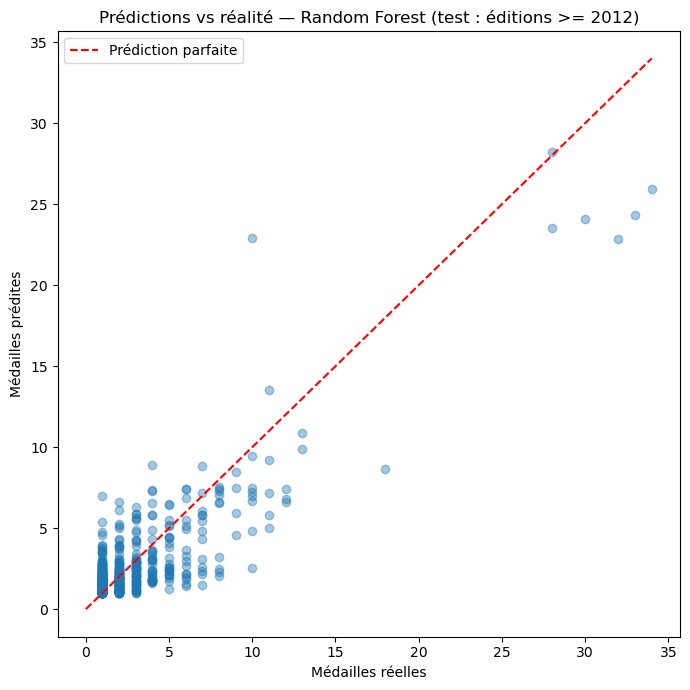

In [15]:
preds_test = np.clip(model.predict(X_test), 0, None)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, preds_test, alpha=0.4)
max_val = max(y_test.max(), preds_test.max())
plt.plot([0, max_val], [0, max_val], 'r--', label="Prédiction parfaite")
plt.xlabel("Médailles réelles")
plt.ylabel("Médailles prédites")
plt.title(f"Prédictions vs réalité — {meilleur_nom} (test : éditions >= {annee_coupure})")
plt.legend()
plt.tight_layout()
plt.savefig("graphiques/scatter_pred_vs_reel.png", dpi=150, bbox_inches="tight")
plt.show()

 5. Interprétation — quelles variables comptent le plus ?


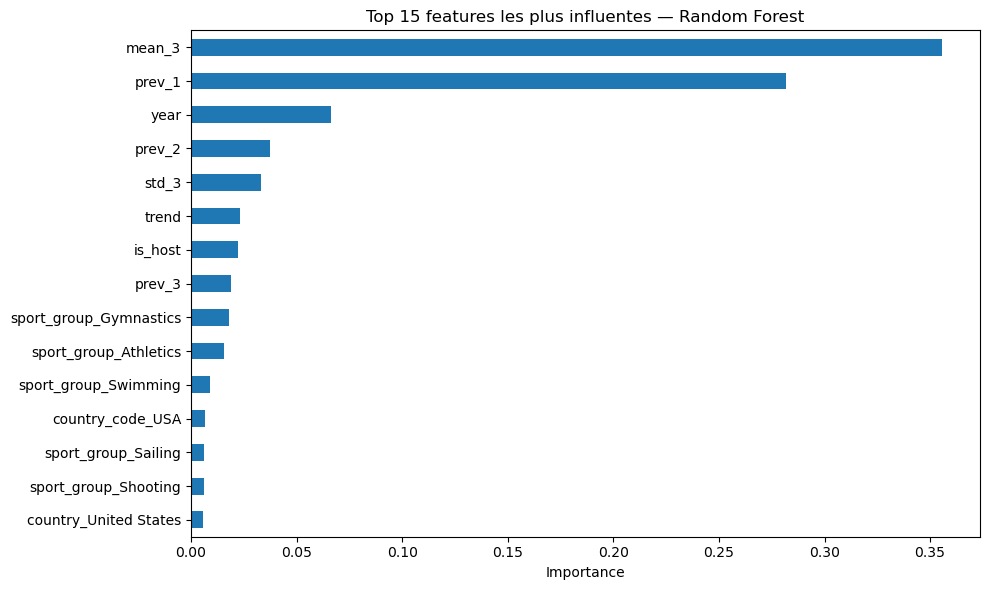

In [16]:
if hasattr(model, "feature_importances_"):
    importances = pd.Series(model.feature_importances_, index=X.columns)
    top_importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    top_importances.sort_values().plot(kind="barh")
    plt.title(f"Top 15 features les plus influentes — {meilleur_nom}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("graphiques/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    coefs = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False).head(15)
    print(coefs)

**Lecture attendue** : les variables `mean_3`, `prev_1` et `trend` devraient dominer - ce qui confirme logiquement que le meilleur prédicteur du futur proche est le passé récent. La variable `is_host` devrait aussi apparaître, conformément à l'effet observé en section 2.

 6. Prédiction du nombre de médailles — JO 2028

C'est le cœur de la problématique : **pour chaque pays et chaque sport, combien de médailles est-il susceptible de remporter en 2028 ?**

On reconstruit, pour chaque couple (pays, sport) déjà observé dans l'historique, une ligne « 2028 » à partir des **3 dernières éditions réellement disputées** (pas une simple duplication de la dernière valeur connue, qui annulerait artificiellement la tendance). L'effet hôte est appliqué : en 2028, c'est les **États-Unis** qui organisent les Jeux.

In [17]:
future_rows = []

for (country, country_code, sport_group), group in df_ml_raw.groupby(['country', 'country_code', 'sport_group']):
    group = group.sort_values('year')

    derniers = group['medal_count'].tail(3).tolist()
    derniers = derniers[::-1]  # du plus récent au plus ancien : [n-1, n-2, n-3]
    while len(derniers) < 3:
        derniers.append(0)

    prev_1, prev_2, prev_3 = derniers
    mean_3 = np.mean(derniers)
    trend  = prev_1 - prev_2
    std_3  = np.std(derniers, ddof=1) if len(set(derniers)) > 1 else 0
    is_host = int(HOSTS.get(2028) == country_code)

    future_rows.append({
        "year": 2028,
        "country": country,
        "country_code": country_code,
        "sport_group": sport_group,
        "prev_1": prev_1, "prev_2": prev_2, "prev_3": prev_3,
        "mean_3": mean_3, "trend": trend, "std_3": std_3,
        "is_host": is_host,
    })

future_df = pd.DataFrame(future_rows)
print(f"{len(future_df)} couples pays/sport à prédire pour 2028")
future_df.head()

710 couples pays/sport à prédire pour 2028


,year,country,country_code,sport_group,prev_1,prev_2,prev_3,mean_3,trend,std_3,is_host
0,2028,Algeria,ALG,Athletics,1,2,1,1.333333,-1,0.57735,0
1,2028,Algeria,ALG,Boxing,1,1,2,1.333333,0,0.57735,0
2,2028,Algeria,ALG,Gymnastics,1,0,0,0.333333,1,0.57735,0
3,2028,Argentina,ARG,Athletics,1,2,1,1.333333,-1,0.57735,0
4,2028,Argentina,ARG,Boxing,1,1,1,1.000000,0,0.00000,0


In [19]:
# Encodage identique à l'entraînement, puis alignement strict sur les colonnes de X
future_encoded = pd.get_dummies(future_df, columns=['country', 'country_code', 'sport_group'])
future_encoded = future_encoded.reindex(columns=X.columns, fill_value=0)

preds_2028 = model.predict(future_encoded)
future_df['predicted_medals_2028'] = np.clip(preds_2028, 0, None).round(1)

print("Top 15 couples pays / sport les plus prometteurs pour 2028 :")
top_predictions = future_df.sort_values('predicted_medals_2028', ascending=False).head(15)
print(top_predictions[['country', 'sport_group', 'predicted_medals_2028']].to_string(index=False))

Top 15 couples pays / sport les plus prometteurs pour 2028 :
                   country sport_group  predicted_medals_2028
             United States   Athletics                   29.1
             United States    Swimming                   28.5
                      USSR   Athletics                   28.0
German Democratic Republic    Swimming                   27.7
German Democratic Republic   Athletics                   24.2
                      USSR  Gymnastics                   18.6
                 Australia    Swimming                   14.4
German Democratic Republic      Rowing                   11.5
    Unified Team (ex USSR)   Athletics                    9.6
             United States  Gymnastics                    9.5
German Democratic Republic  Gymnastics                    9.5
                     China    Swimming                    9.4
                     Kenya   Athletics                    9.0
                      USSR    Swimming                    8.7
         

 Combien de médailles par sport, toutes nations confondues ?

 sur chaque sport, combien de médailles au total est-il susceptible d'y avoir en 2028, et quel pays est pressenti pour dominer cette discipline ?

In [20]:
medailles_par_sport_2028 = (future_df.groupby('sport_group')['predicted_medals_2028']
                             .sum().round(1).sort_values(ascending=False))
print("Médailles totales prédites par sport — JO 2028")
print(medailles_par_sport_2028.to_string())

leader_par_sport = (future_df.sort_values('predicted_medals_2028', ascending=False)
                     .groupby('sport_group').first()
                     .reset_index()[['sport_group', 'country', 'predicted_medals_2028']]
                     .rename(columns={'country': 'pays_leader', 'predicted_medals_2028': 'medailles_predites'}))
print("\nPays leader prédit par sport — JO 2028")
print(leader_par_sport.to_string(index=False))

Médailles totales prédites par sport — JO 2028
sport_group
Athletics                278.9
Swimming                 214.4
Boxing                   150.1
Shooting                 132.1
Gymnastics               129.7
Rowing                   100.8
Fencing                   89.3
Wrestling Greco-Roman     84.9
Cycling Track             78.2
Sailing                   75.4
Diving                    57.7
Cycling Road              46.7
Football                  42.6
Equestrian Jumping        41.2
Water Polo                27.5

Pays leader prédit par sport — JO 2028
          sport_group                 pays_leader  medailles_predites
            Athletics               United States                29.1
               Boxing                        USSR                 6.2
         Cycling Road               United States                 3.0
        Cycling Track               Great Britain                 7.2
               Diving                       China                 7.2
   Equestrian Ju

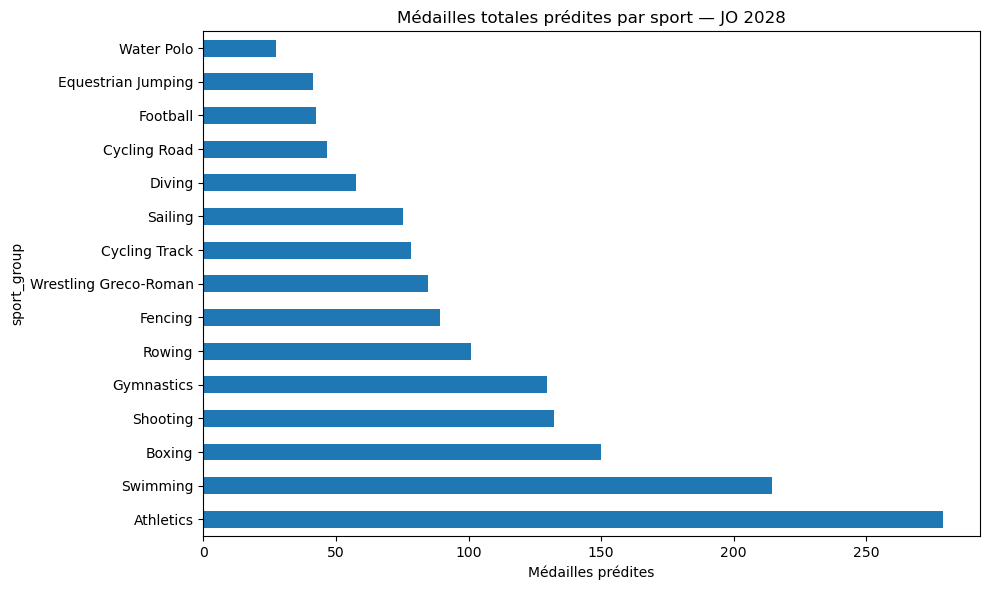

In [21]:
# Visualisation : médailles prédites par sport (vision storytelling)
plt.figure(figsize=(10, 6))
medailles_par_sport_2028.plot(kind="barh")
plt.title("Médailles totales prédites par sport — JO 2028")
plt.xlabel("Médailles prédites")
plt.tight_layout()
plt.savefig("graphiques/medailles_par_sport_2028.png", dpi=150, bbox_inches="tight")
plt.show()

 7. Estimation du type de médaille (Or / Argent / Bronze)

In [22]:
ratios = df.groupby(['country', 'sport_group', 'medal']).size().reset_index(name='n')
ratios_pivot = ratios.pivot_table(index=['country', 'sport_group'],
                                   columns='medal', values='n', fill_value=0)
ratios_pct = ratios_pivot.div(ratios_pivot.sum(axis=1), axis=0).reset_index()

future_avec_type = future_df.merge(ratios_pct, on=['country', 'sport_group'], how='left')

for col in ['Gold', 'Silver', 'Bronze']:
    if col not in future_avec_type.columns:
        future_avec_type[col] = 0
    future_avec_type[col] = future_avec_type[col].fillna(1 / 3)
    future_avec_type[f'predicted_{col.lower()}'] = (
        future_avec_type['predicted_medals_2028'] * future_avec_type[col]
    ).round(1)

apercu = future_avec_type.sort_values('predicted_medals_2028', ascending=False).head(10)
print(apercu[['country', 'sport_group', 'predicted_medals_2028',
              'predicted_gold', 'predicted_silver', 'predicted_bronze']].to_string(index=False))

                   country sport_group  predicted_medals_2028  predicted_gold  predicted_silver  predicted_bronze
             United States   Athletics                   29.1            12.2               9.4               7.5
             United States    Swimming                   28.5            12.6               9.0               7.0
                      USSR   Athletics                   28.0             8.8               8.1              11.1
German Democratic Republic    Swimming                   27.7            11.4               9.6               6.6
German Democratic Republic   Athletics                   24.2             8.4               8.0               7.8
                      USSR  Gymnastics                   18.6             7.4               6.8               4.4
                 Australia    Swimming                   14.4             4.6               5.1               4.7
German Democratic Republic      Rowing                   11.5             7.9           

 8. Côtes des athlètes (complément)

Le dataset ne contient que le nom de l'athlète, l'année, le sport et la médaille — aucune variable individuelle (âge, classement, données physiques). On ne peut donc pas entraîner un modèle supervisé par athlète. À la place, on calcule une **côte** (un score descriptif, pas une prédiction) basée sur l'historique réel de chaque athlète.

In [23]:
df_athletes = df.copy()
df_athletes['athletes'] = df_athletes['athletes'].astype(str)
df_athletes = df_athletes.assign(athlete=df_athletes['athletes'].str.split(',')).explode('athlete')
df_athletes['athlete'] = df_athletes['athlete'].str.strip()
df_athletes = df_athletes[df_athletes['athlete'] != '']

cotes = df_athletes.groupby(['athlete', 'country', 'sport_group']).agg(
    total_medailles=('medal', 'count'),
    or_count=('medal', lambda m: (m == 'Gold').sum()),
    argent_count=('medal', lambda m: (m == 'Silver').sum()),
    bronze_count=('medal', lambda m: (m == 'Bronze').sum()),
    derniere_annee=('year', 'max'),
).reset_index()

cotes['recence'] = (cotes['derniere_annee'] >= 2008).astype(int)
cotes['cote'] = (
    cotes['or_count'] * 3 + cotes['argent_count'] * 2 + cotes['bronze_count'] * 1
) * (1 + 0.5 * cotes['recence'])

cotes = cotes.sort_values('cote', ascending=False)
print("Top 15 athlètes — côte de performance")
print(cotes.head(15)[['athlete', 'country', 'sport_group', 'total_medailles', 'or_count', 'cote']].to_string(index=False))

Top 15 athlètes — côte de performance
            athlete        country sport_group  total_medailles  or_count  cote
     Michael PHELPS  United States    Swimming               14        12  60.0
    Larisa LATYNINA           USSR  Gymnastics               18         9  41.0
  Nikolay ANDRIANOV           USSR  Gymnastics               15         7  34.0
        Paavo NURMI        Finland   Athletics               12         9  33.0
       BILES Simone  United States  Gymnastics                8         6  31.5
     Boris SHAKHLIN           USSR  Gymnastics               13         7  31.0
         Sawao KATO          Japan  Gymnastics               12         8  31.0
                nan  United States    Swimming               12         7  30.0
Edoardo MANGIAROTTI          Italy     Fencing               13         6  30.0
         Mark SPITZ  United States    Swimming               11         9  30.0
     Vera CÁSLAVSKÁ Czechoslovakia  Gymnastics               11         7  29.0
  

9. Sauvegarde des résultats

On exporte le modèle entraîné et les tables de résultats, pour qu'ils soient directement exploitables par l'application Streamlit de data storytelling, sans avoir à relancer l'entraînement.

In [24]:
import pickle, os

os.makedirs("app", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

with open("app/model.pkl", "wb") as f:
    pickle.dump({"model": model, "columns": list(X.columns), "nom_modele": meilleur_nom}, f)

df.to_csv("data/processed/df_cleaned.csv", index=False)
future_avec_type.to_csv("data/processed/predictions_2028.csv", index=False)
cotes.to_csv("data/processed/cotes_athletes.csv", index=False)
resultats_df.to_csv("data/processed/comparaison_modeles.csv", index=False)

print(f"Modèle '{meilleur_nom}' sauvegardé dans app/model.pkl")
print("Tables de résultats sauvegardées dans data/processed/")

Modèle 'Random Forest' sauvegardé dans app/model.pkl
Tables de résultats sauvegardées dans data/processed/


 Conclusion de la modélisation

- Le modèle Random Forest a été retenu après comparaison avec une Régression Linéaire et un Gradient Boosting, sur un split chronologique (et non aléatoire) afin d'éviter toute fuite de données temporelles.
- Les variables les plus influentes sont liées à l'historique récent (`mean_3`, `prev_1`, `trend`) et à l'effet pays hôte (`is_host`).
- Les prédictions 2028 sont disponibles par couple pays/sport, avec une estimation du type de médaille (Or/Argent/Bronze) basée sur les ratios historiques.
- Une côte descriptive des athlètes complète l'analyse, sans prétendre à une prédiction individuelle (limite du dataset).

Ces résultats sont prêts à être exploités par l'application Streamlit pour le data storytelling.